# 02 · Exploratory Data Analysis
**Project**: War Shocks & Global Financial Risk Spillover  
**Input**: `data/processed/` — outputs from `01_data_collection.ipynb`  
**Output**: `outputs/figures/fig1–fig6`, `outputs/tables/table_adf_tests`, `table_war_vs_calm`

### Role in the research logic
Each figure and table below directly motivates a downstream modelling decision:

| Output | Finding | Downstream implication |
|--------|---------|----------------------|
| Fig 1 | Vol spikes coincide with war events | War regime analysis in nb03/nb08 |
| Fig 2 | Fat tails in all markets | Linear VAR mis-specified → LSTM/GRU justified |
| Fig 3 | Higher correlations during war | Cross-market spillover analysis (nb03) |
| Fig 4 | Short-term drawdowns at event onset | War shocks transmit quickly, non-linearly |
| Fig 5 | Brent + VIX spike during war | Energy-fear transmission channel confirmed |
| Fig 6 | C/A >> B/A | GFC/COVID dominate; crisis control essential |
| Table 1 | All vol series stationary | No differencing needed — VAR inputs valid |
| Table 2 | B/A ratio per market | War premium quantified; regime design for nb08 |

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import pandas as pd
from src.data_loader import DATA_RAW_DIR, DATA_PROC_DIR
from src.eda import (
    plot_volatility_timeseries,
    plot_return_distributions,
    plot_correlation_heatmaps,
    plot_event_windows,
    plot_macro_war_linkage,
    run_adf_tests,
    war_vs_calm_stats,
    plot_crisis_decomposition,
)

END = "2025-12-31"

---
## 1  Load Processed Data

In [2]:
combined   = pd.read_excel(f"{DATA_PROC_DIR}/all_variables_aligned.xlsx",
                           index_col=0, parse_dates=True)
returns_df = pd.read_excel(f"{DATA_PROC_DIR}/log_returns.xlsx",
                           index_col=0, parse_dates=True)
vol_df     = pd.read_excel(f"{DATA_PROC_DIR}/rolling_volatility.xlsx",
                           index_col=0, parse_dates=True)
war_dummy  = pd.read_excel(f"{DATA_PROC_DIR}/war_dummies.xlsx",
                           index_col=0, parse_dates=True)
events     = pd.read_excel(f"{DATA_RAW_DIR}/war_events.xlsx",
                           parse_dates=["start_date", "end_date"])

print(f"combined   : {combined.shape}   {combined.index[0].date()} ~ {combined.index[-1].date()}")
print(f"returns_df : {returns_df.shape}")
print(f"vol_df     : {vol_df.shape}")
print(f"war_dummy  : {war_dummy.shape}  columns: {list(war_dummy.columns)}")
print(f"events     : {len(events)} war events")
print()
print(war_dummy.sum().rename("days_active").to_frame().T)
events[["event_name", "start_date", "end_date"]]

combined   : (6538, 16)   2000-01-03 ~ 2025-12-30
returns_df : (6538, 16)
vol_df     : (6538, 8)
war_dummy  : (6538, 5)  columns: ['mideast_war', 'high_intensity', 'gfc_crisis', 'covid_crisis', 'any_crisis']
events     : 7 war events

             mideast_war  high_intensity  gfc_crisis  covid_crisis  any_crisis
days_active          271              14         209           168         377


,event_name,start_date,end_date
0,Iraq War,2003-03-20,2003-05-01
1,Lebanon War,2006-07-12,2006-08-14
2,Gaza War 2008,2008-12-27,2009-01-18
3,Gaza War 2014,2014-07-08,2014-08-26
4,ISIS Iraq escalation,2014-06-10,2014-12-09
5,US-Iran crisis,2020-01-03,2020-01-08
6,Israel-Hamas War,2023-10-07,2024-01-19


---
## 2  Fig 1 · Rolling Volatility + War Events

**What to look for**: GFC (2008–09) and COVID (2020) dominate as the largest spikes,
confirming they operate on a different scale than Middle East war events alone.
War events are visible as secondary spikes — particularly Israel-Hamas 2023 and Israel-Iran 2024.
This motivates the four-regime crisis control in Table 2.

  Saved → c:\Users\cn_55\Desktop\上课文件\2 - D200\Problem Set\D200_PS\Project\outputs\figures\fig1_volatility_timeseries.png


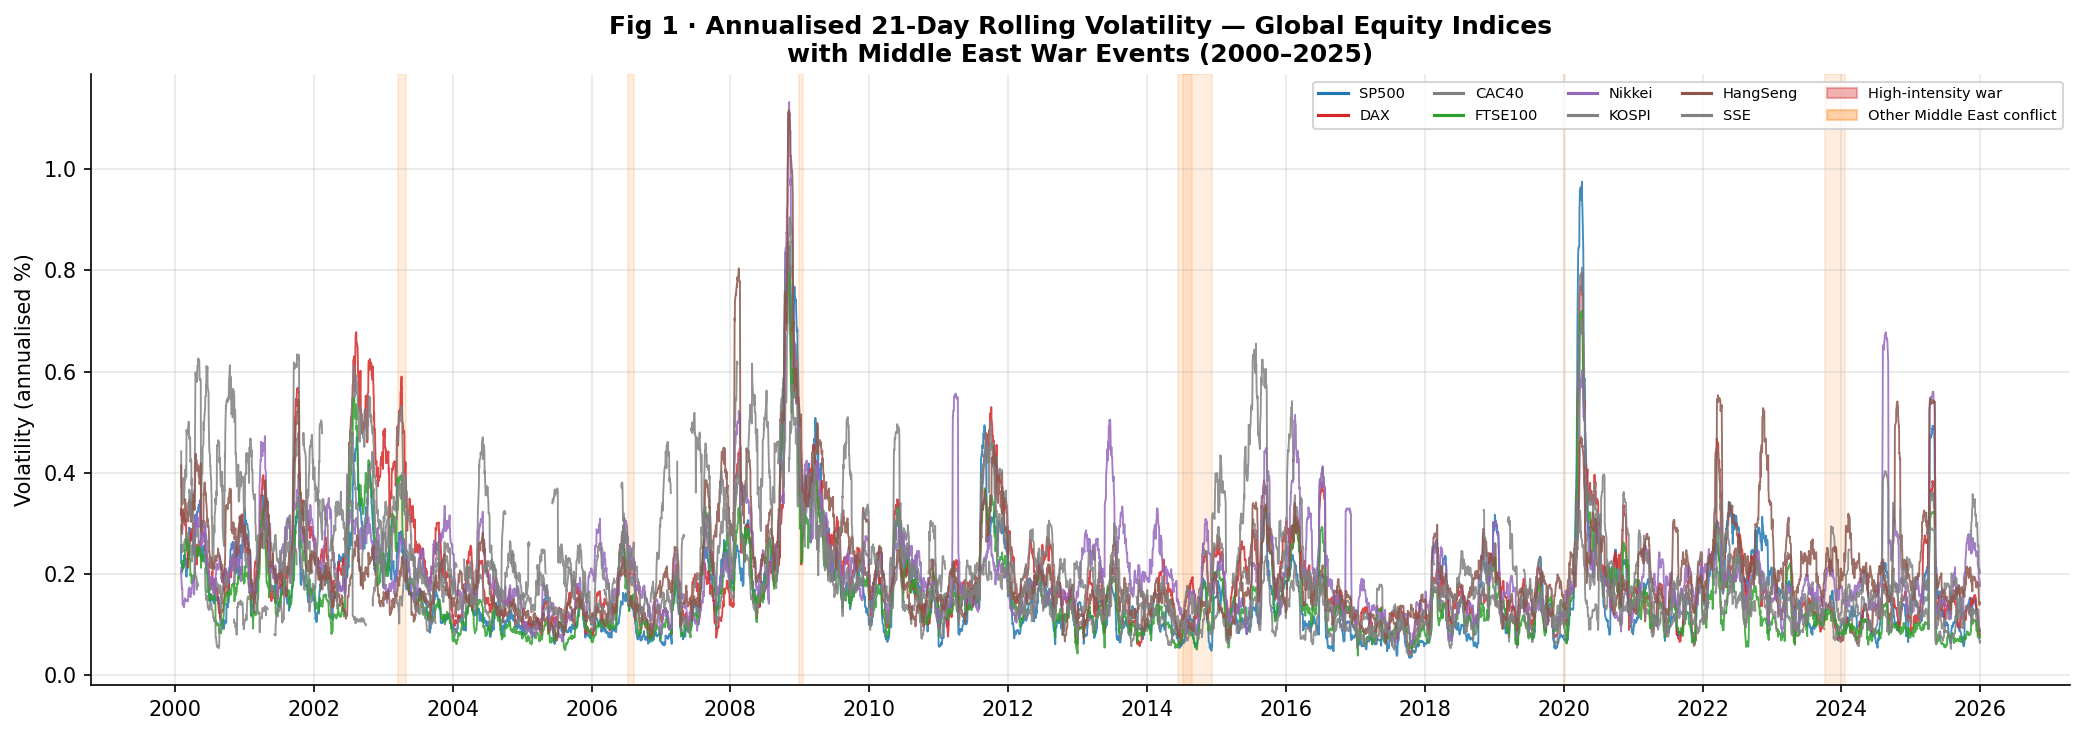

In [3]:
plot_volatility_timeseries(vol_df, events, end_date=END)

---
## 3  Fig 2 · Return Distributions vs Normal

**What to look for**: excess kurtosis significantly above 3 (normal benchmark) in all markets.
Fat tails invalidate the Gaussian assumption of linear VAR.
This is the statistical justification for using LSTM and GRU.

  Saved → c:\Users\cn_55\Desktop\上课文件\2 - D200\Problem Set\D200_PS\Project\outputs\figures\fig2_return_distributions.png


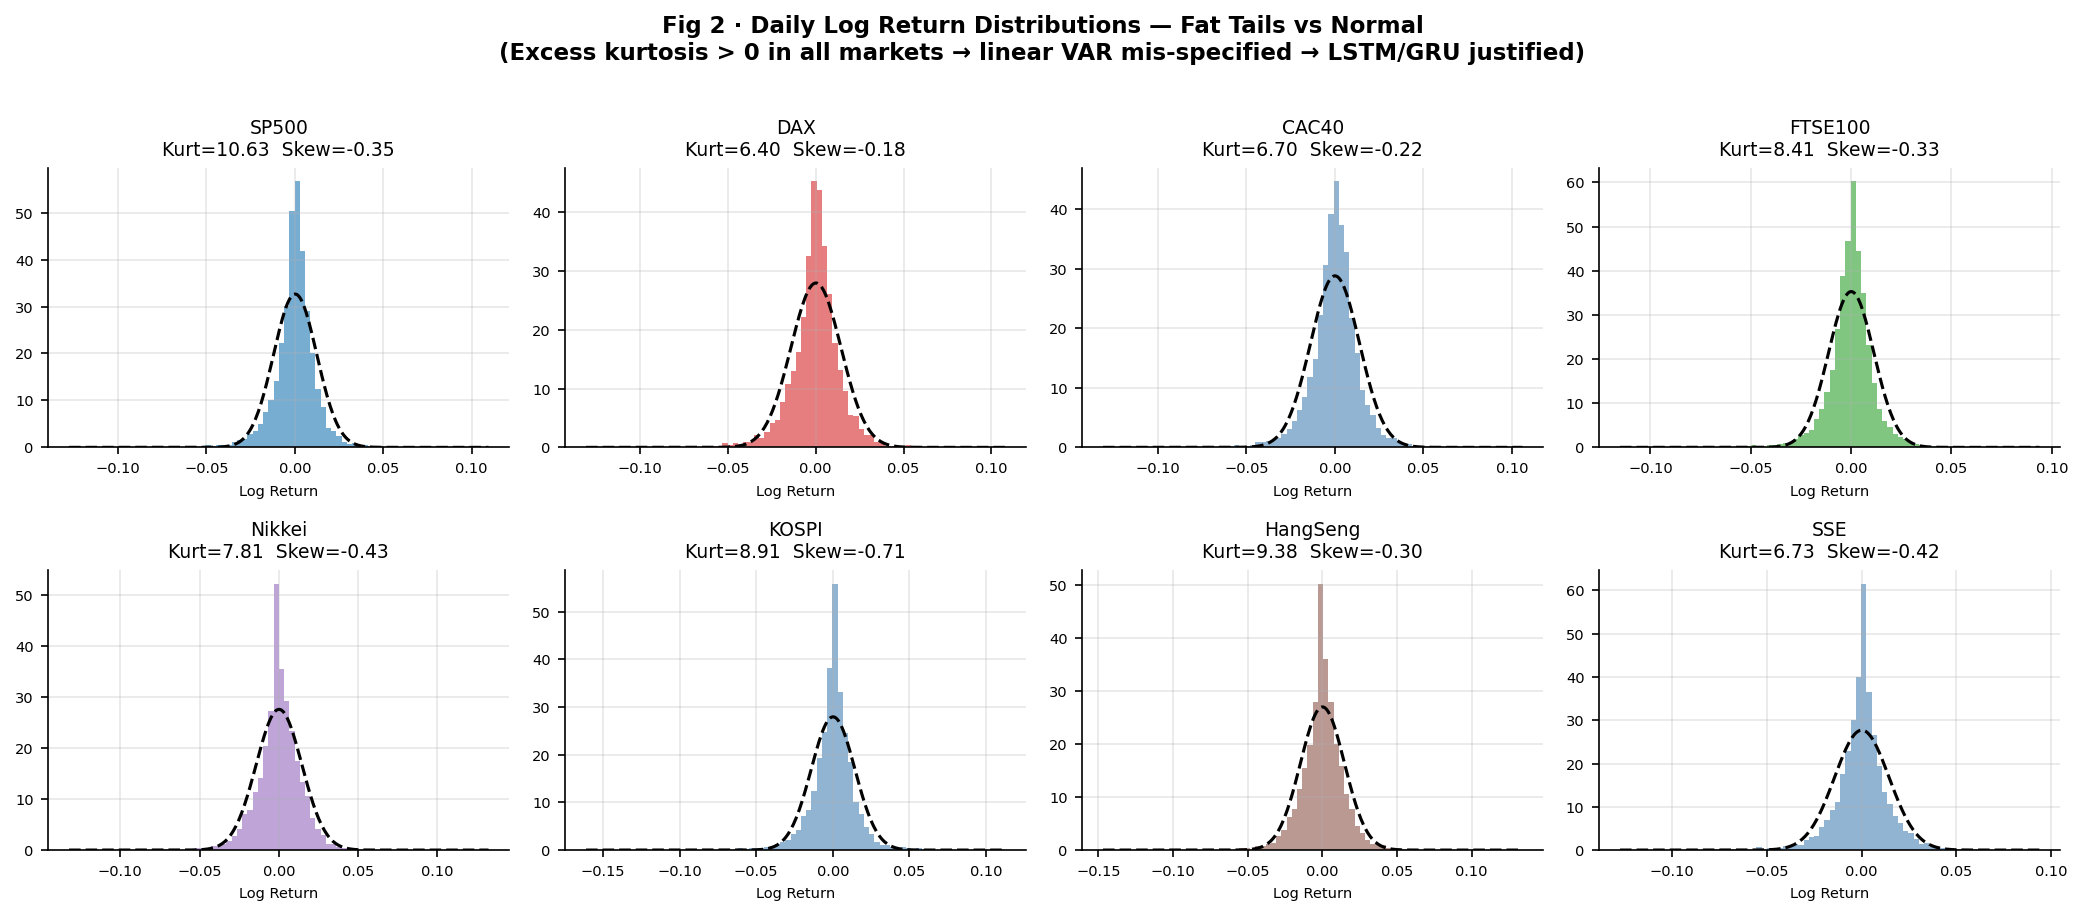

In [4]:
plot_return_distributions(returns_df)

---
## 4  Fig 3 · Correlation Heatmaps: Calm vs War

**What to look for**: warmer colours (higher correlations) in the War panel indicate
that markets move together more during conflict — evidence of risk contagion.
This cross-market co-movement is the mechanism the DY spillover index (nb03) formalises.

c:\Users\cn_55\Desktop\上课文件\2 - D200\Problem Set\D200_PS\Project\src\eda.py:232: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  Saved → c:\Users\cn_55\Desktop\上课文件\2 - D200\Problem Set\D200_PS\Project\outputs\figures\fig3_correlation_heatmaps.png


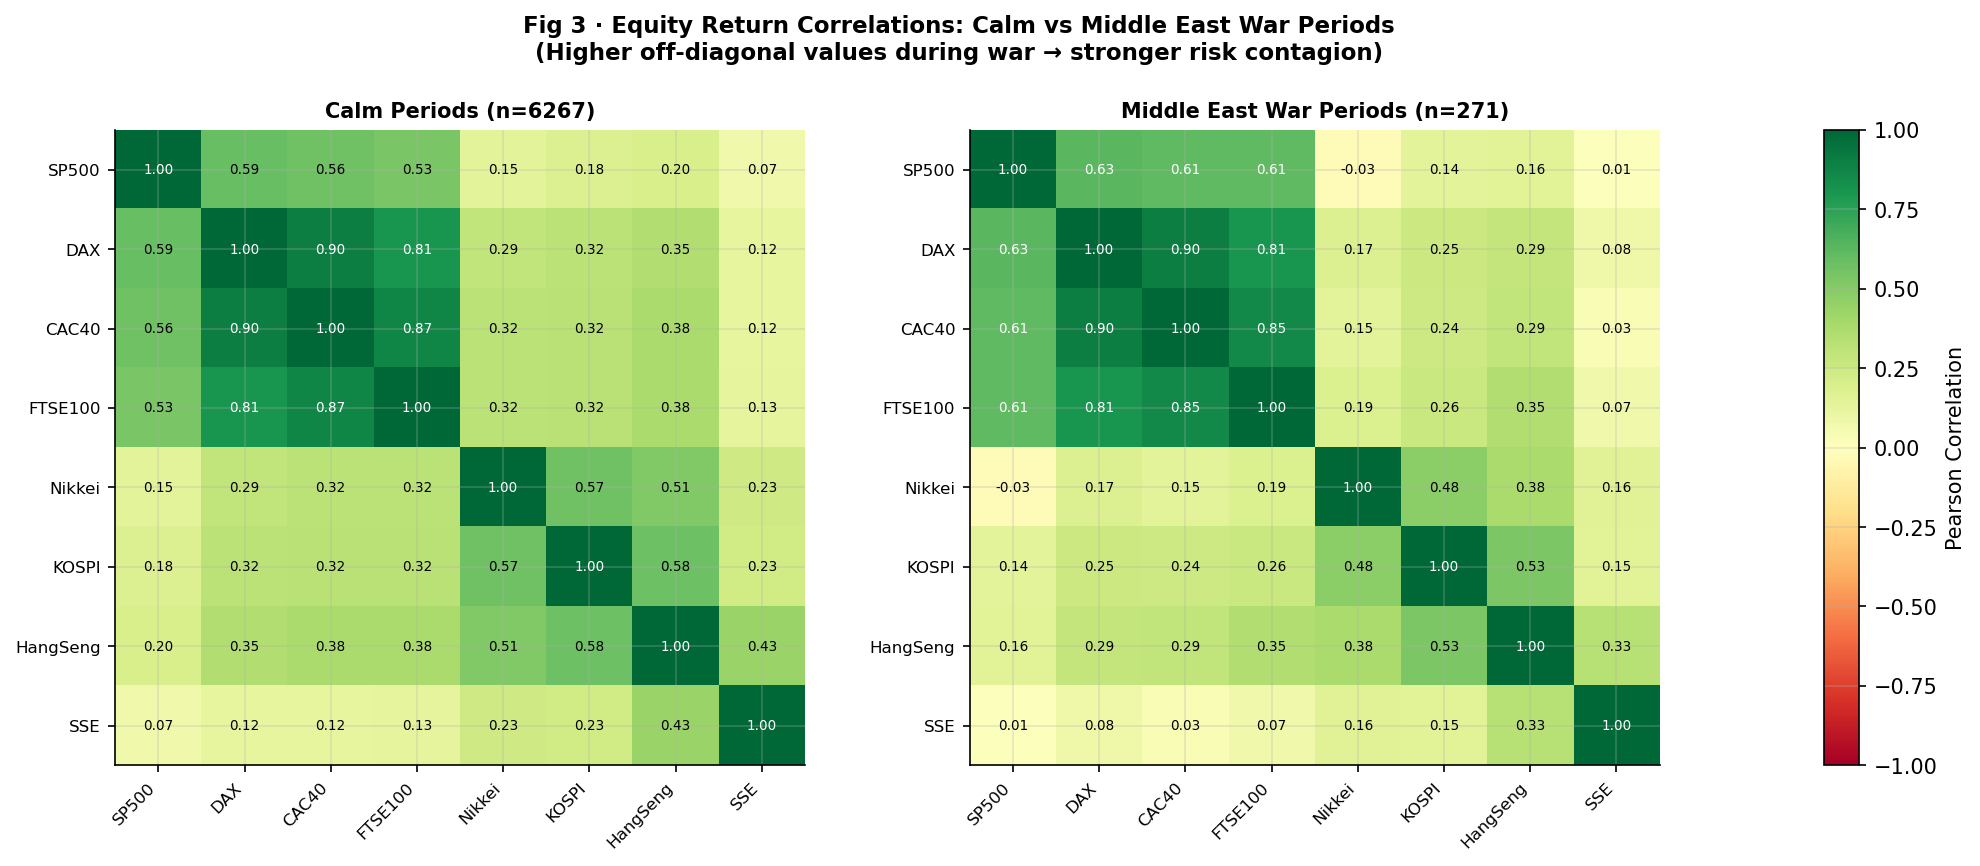

In [5]:
plot_correlation_heatmaps(returns_df, war_dummy)

---
## 5  Fig 4 · Event Study: Cumulative Returns Around War Start

**What to look for**: market drawdowns in the first ~20 trading days after event start.
The heterogeneity across events (some sharp drops, some muted) is itself evidence
that war shocks are non-linear and regime-dependent — exactly where fixed-coefficient
VAR under-fits and deep learning models have an advantage.

  Saved → c:\Users\cn_55\Desktop\上课文件\2 - D200\Problem Set\D200_PS\Project\outputs\figures\fig4_event_windows.png


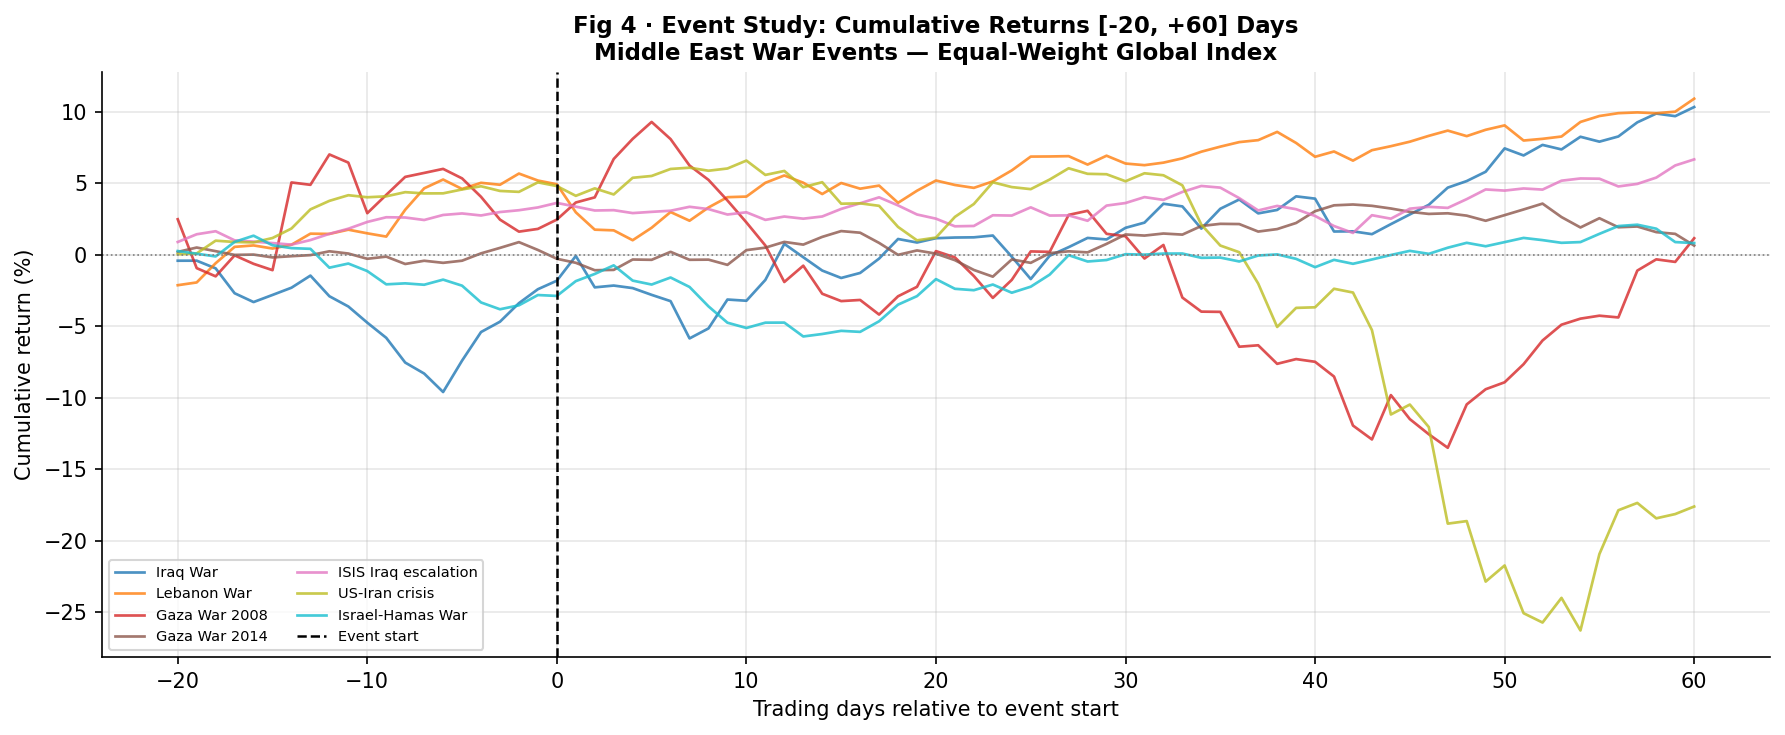

In [6]:
plot_event_windows(returns_df, events, pre=20, post=60)

---
## 6  Fig 5 · Oil / Gold / VIX Linkage During War Periods

**What to look for**: Brent crude and VIX spikes during Middle East conflicts —
this is the core transmission channel of the research motivation
(war → energy supply disruption → financial market stress).
Also note any anomalous Gold behaviour during Israel-Iran 2024.

  Saved → c:\Users\cn_55\Desktop\上课文件\2 - D200\Problem Set\D200_PS\Project\outputs\figures\fig5_macro_war_linkage.png


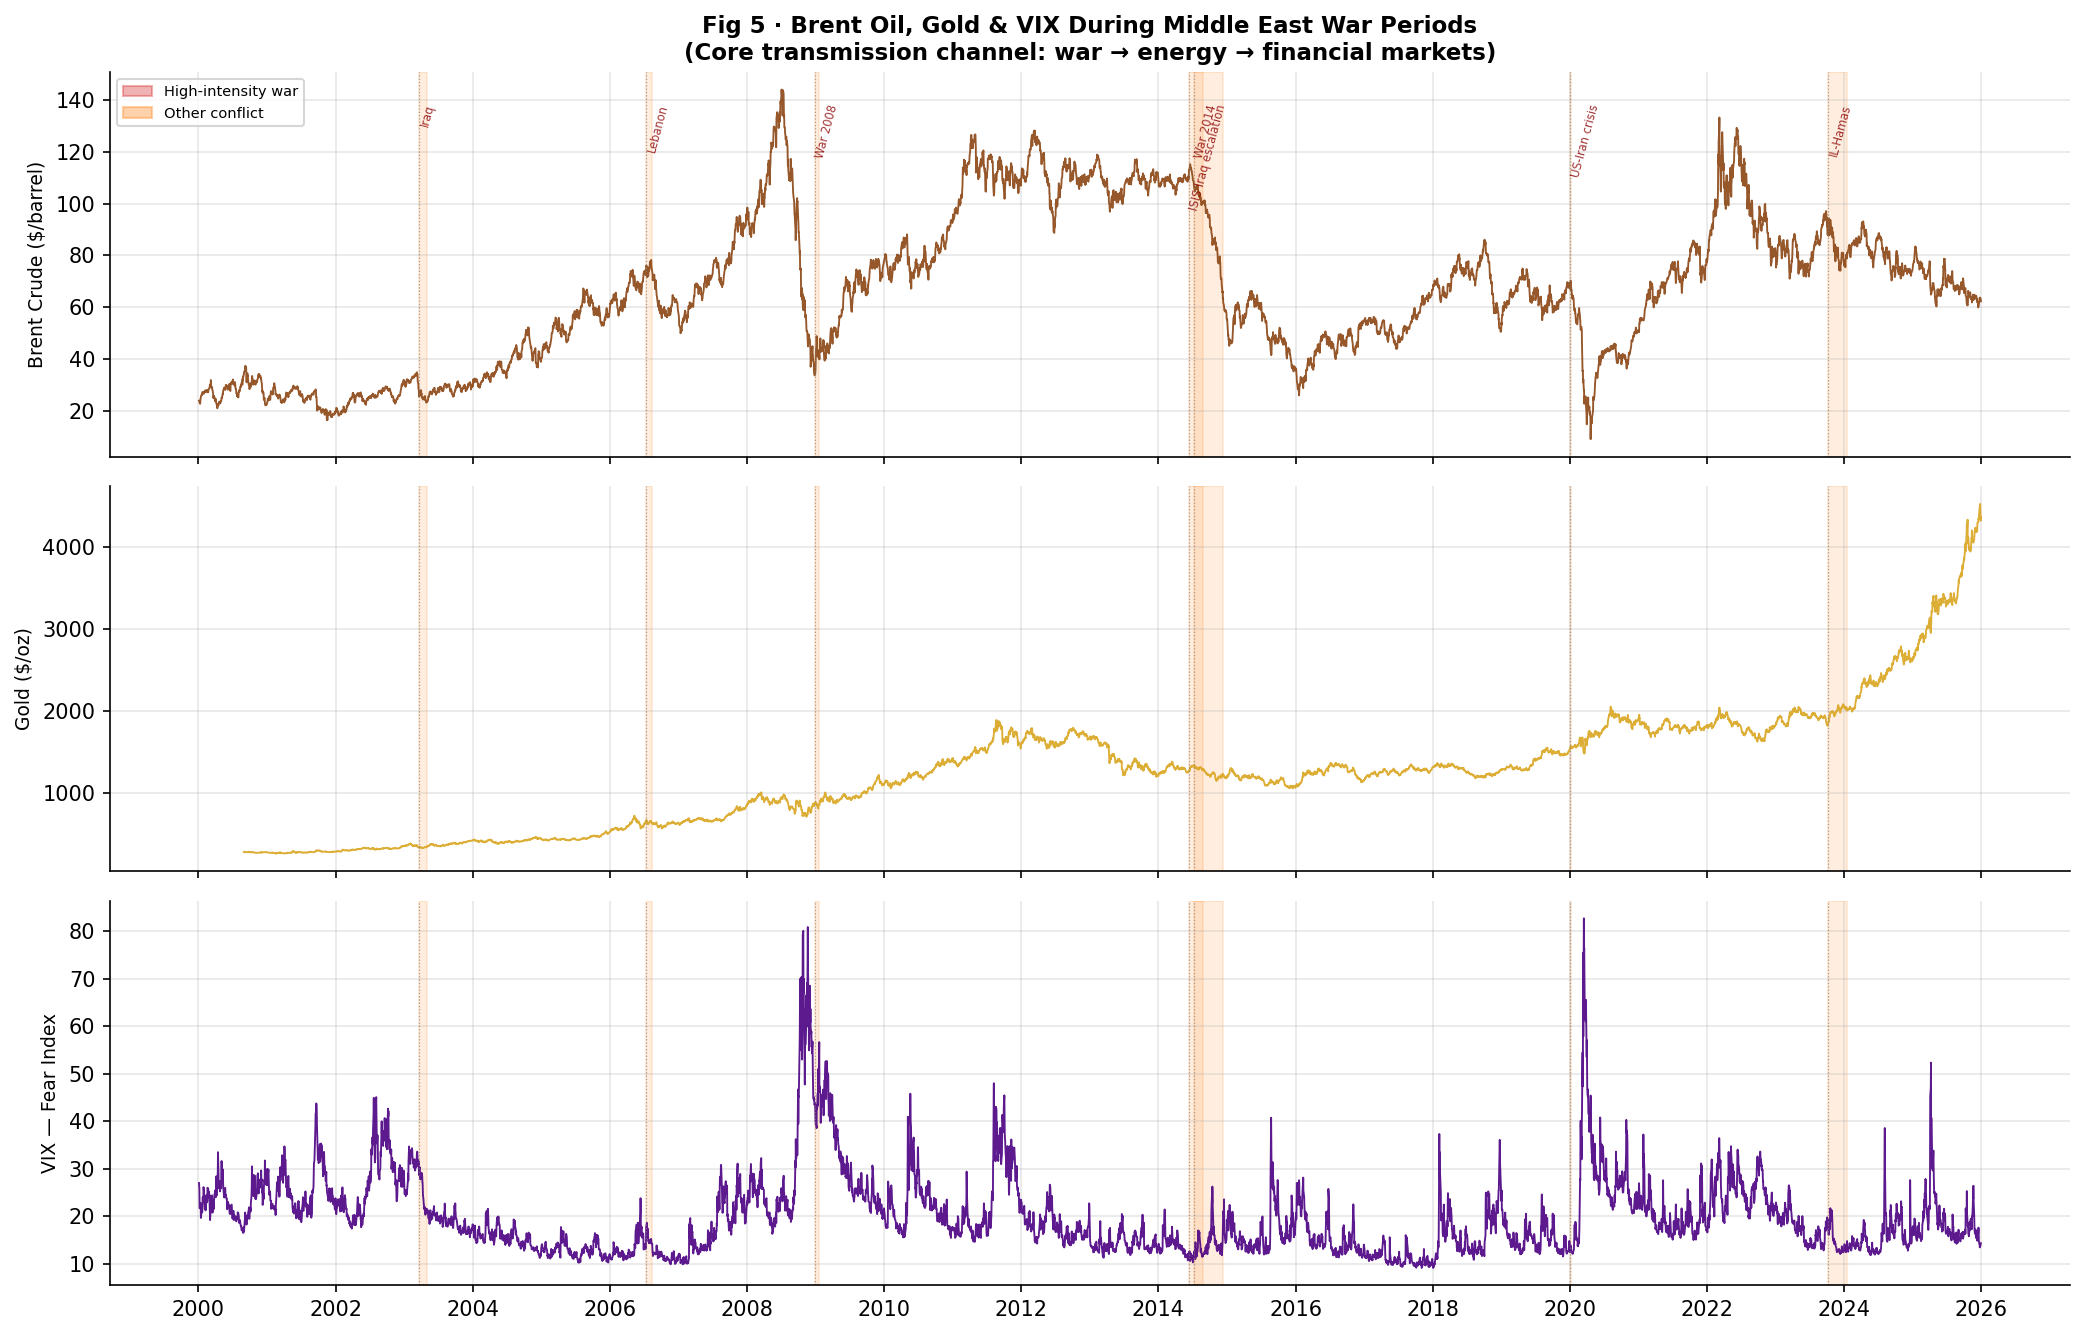

In [7]:
plot_macro_war_linkage(combined, events, end_date=END)

---
## 7  Table 1 · ADF Stationarity Tests

**What to look for**: all p-values < 0.05 (stationary at 5% level).
VAR requires stationary inputs. Non-stationary series must be first-differenced.
If any series fails, revisit the volatility computation in nb01.

In [8]:
adf_results = run_adf_tests(vol_df)


[Table 1 — ADF Stationarity Tests on Volatility Series]
          ADF Statistic  p-value  1% Critical  5% Critical Stationary?
Series                                                                
SP500           -7.0681      0.0      -3.4314      -2.8620       ✅ Yes
DAX             -6.4742      0.0      -3.4314      -2.8620       ✅ Yes
CAC40           -6.9072      0.0      -3.4314      -2.8620       ✅ Yes
FTSE100         -7.0360      0.0      -3.4314      -2.8620       ✅ Yes
Nikkei          -7.9756      0.0      -3.4314      -2.8620       ✅ Yes
KOSPI           -6.2228      0.0      -3.4314      -2.8620       ✅ Yes
HangSeng        -6.9256      0.0      -3.4314      -2.8620       ✅ Yes
SSE             -5.0927      0.0      -3.4316      -2.8621       ✅ Yes

  Saved → c:\Users\cn_55\Desktop\上课文件\2 - D200\Problem Set\D200_PS\Project\outputs\tables\table_adf_tests.xlsx


---
## 8  Table 2 · Four-Regime Volatility Decomposition

The naive two-regime comparison (war=1 vs war=0) can produce a counter-intuitive result which is
war-period volatility *lower* than calm, because GFC and COVID fall in the war=0 window
and inflate the calm baseline.

The four-regime design isolates each effect cleanly:

| Regime | Definition | Role |
|--------|-----------|------|
| **A: Pure Calm** | war=0, crisis=0 | True baseline |
| **B: War Only**  | war=1, crisis=0 | Clean war effect |
| **C: Crisis Only** | war=0, crisis=1 | GFC / COVID benchmark |
| **D: War+Crisis** | war=1, crisis=1 | Overlap |

**Key outputs**:
- **B/A ratio**: war premium net of crises — feeds into nb08 Table 3 regime analysis
- **C/A ratio**: confirms GFC/COVID are the dominant vol driver
- **t-stat (B vs A)**: statistical significance of the war effect

In [9]:
summary_table = war_vs_calm_stats(vol_df, war_dummy)


[Table 2 — Four-Regime Volatility Decomposition]
  A=Pure Calm  B=War Only  C=Crisis Only  D=War+Crisis

          A: Pure Calm  B: War Only  C: Crisis Only  D: War+Crisis  B/A Ratio  C/A Ratio  t-stat (B vs A)  p-value Significant?
Market                                                                                                                         
SP500           0.1505       0.1235          0.3995         0.3574      0.821      2.655           -7.290   0.0000            ✅
DAX             0.1875       0.1840          0.3797         0.3095      0.981      2.025           -0.452   0.6513            ❌
CAC40           0.1820       0.1797          0.3807         0.3474      0.987      2.091           -0.339   0.7346            ❌
FTSE100         0.1442       0.1315          0.3490         0.2799      0.912      2.421           -2.517   0.0124            ✅
Nikkei          0.1980       0.1845          0.3635         0.3849      0.932      1.836           -3.555   0.0004            

---
## 9  Fig 6 · Crisis Decomposition Bar Chart

**What to look for**:
- Bar C (orange) >> Bar A (blue) across all markets → GFC/COVID are the dominant volatility driver
- Bar B (red) > Bar A (blue) → war premium is real but modest
- This heterogeneity directly motivates using crisis dummies in the model specifications (nb04–07)

  Saved → c:\Users\cn_55\Desktop\上课文件\2 - D200\Problem Set\D200_PS\Project\outputs\figures\fig6_crisis_decomposition.png


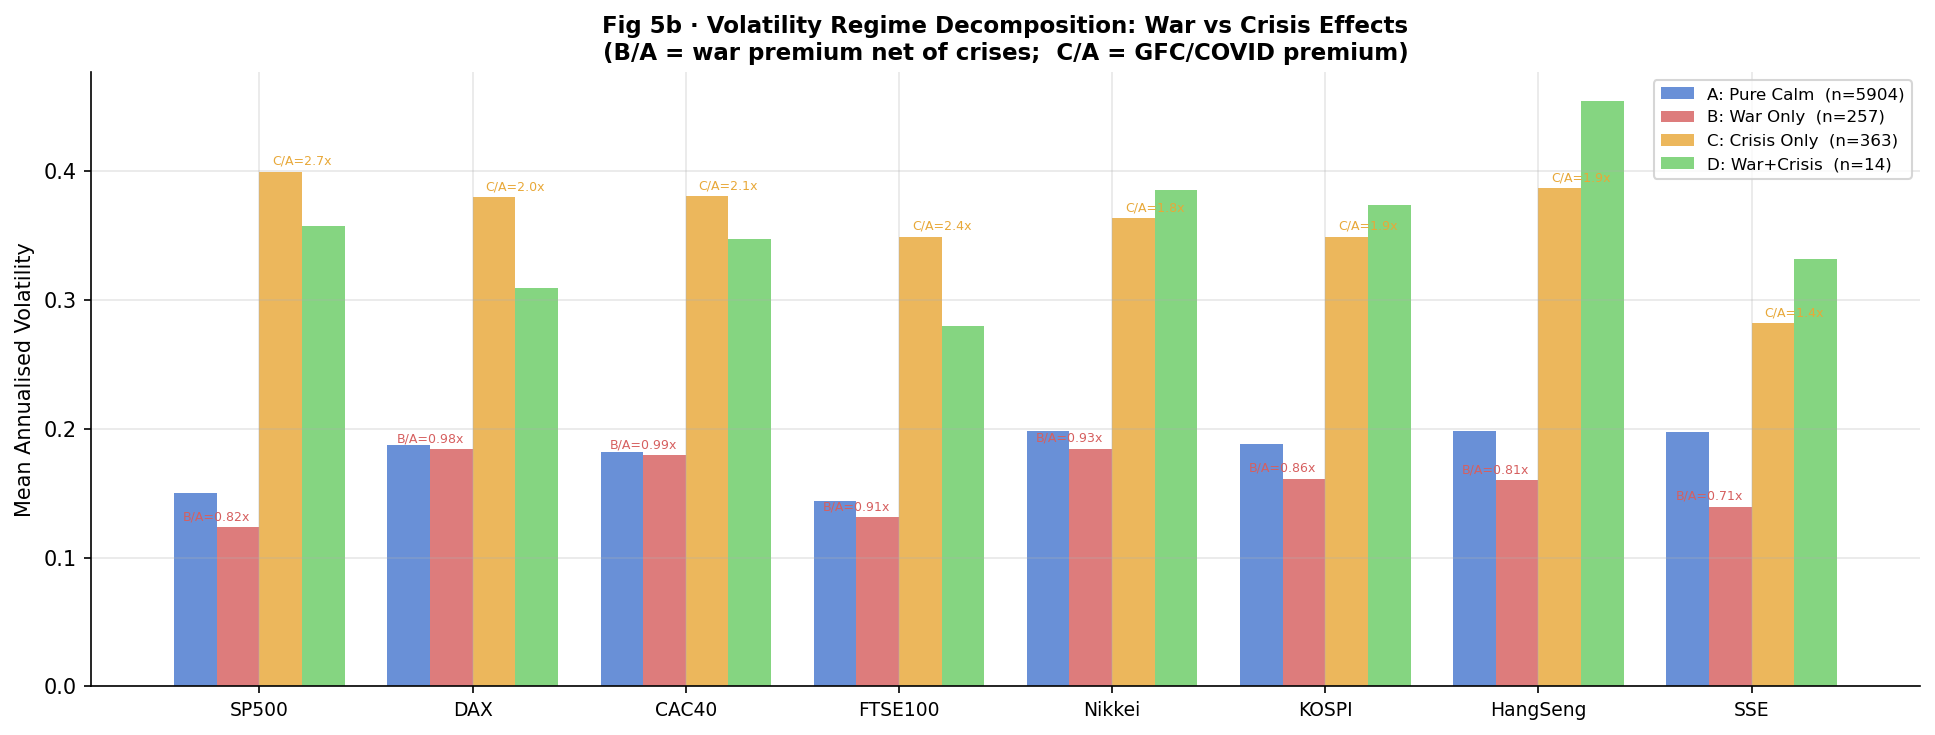

In [10]:
plot_crisis_decomposition(vol_df, war_dummy)

---
**Next → `03_spillover_index.ipynb`**